# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Muhammad Bagas Althaafah]
- **Email:** [cdcc318d6y2290@student.devacademy.id]
- **ID Dicoding:** [CDCC318d6y2290]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh perbedaan kondisi cuaca (weathersit) terhadap jumlah total penyewaan sepeda harian (cnt) sepanjang tahun 2012?
- **Pertanyaan 2:** Apakah terdapat perbedaan pola penyewaan sepeda antara hari kerja (workingday) dan hari libur (holiday) pada setiap jamnya (hr) selama musim gugur (fall)?

## Import Semua Packages/Library yang Digunakan

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Data Wrangling

### Gathering Data

#### Load df ...

In [34]:
# Load data
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

display(day_df.head())
display(hour_df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Kedua dataset memiliki mayoritas kolom yang sama sehingga proses integrasi akan lebih mudah
- Nilai pada kolom fitur cuaca seperti temp, atemp, hum, dan windspeed sudah dalam bentuk ternormalisasi (skala 0 sampai 1), bukan nilai satuan asli (Celsius atau km/jam).
- Kolom cnt (count) merupakan hasil penjumlahan dari pengguna casual dan registered


### Assessing Data

#### Identifying ... problem

In [35]:
# Memeriksa tipe data dan missing values
print("--- Informasi day_df ---")
day_df.info()

print("\n--- Informasi hour_df ---")
hour_df.info()

# Memeriksa duplikasi data
print("\nJumlah duplikasi day_df:", day_df.duplicated().sum())
print("Jumlah duplikasi hour_df:", hour_df.duplicated().sum())

# Memeriksa statistik deskriptif untuk melihat outlier
print("\nStatistik Deskriptif day_df:")
display(day_df.describe())

--- Informasi day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

--- Informasi hour_df ---
<class 'pandas.core.frame.DataFrame'>
Ran

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengonversi kolom dteday pada day_df dan hour_df yang saat ini bertipe object menjadi tipe data datetime agar bisa optimal saat EDA
- Mengubah representasi angka pada kolom season (1: Spring, 2: Summer, dst.), mnth (1: Jan, 2: Feb, dst.), dan weathersit (1: Clear, 2: Misty, dst.) menjadi label teks (string) sehingga grafik mudah dipahami
- Melakukan pengecekan apakah ada nilai yang tidak masuk akal pada kolom numerik, seperti memastikan nilai hum (kelembapan) dan temp tetap berada dalam rentang normal meskipun sudah ternormalisasi.

**Insight:** (Opsional)
- Kualitas data sangat baik, karena tidak ditemukan baris yang duplikat maupun nilai yang hilang (missing values) pada kedua dataset.
- Terdapat ketidaksesuaian tipe data pada kolom dteday (terdeteksi sebagai object) yang jika dibiarkan akan menghambat analisis tren waktu di tahap cleaning.
- Terdapat fitur yang sudah melalui proses scaling karena berdasarkan statistik deskriptif, fitur seperti temp, atemp, hum, dan windspeed memiliki nilai minimum 0 dan maksimum mendekati 1.

### Cleaning Data

#### Fixing ... problem

In [36]:
# 1. Mengubah dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mengubah angka menjadi keterangan
day_df['season'] = day_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'})

# Cek hasil akhir cleaning
day_df.info()
day_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Kolom dteday kini telah berhasil diubah menjadi tipe data datetime64 sehingga bisa melakukan operasi waktu, seperti mengekstraksi tren penyewaan berdasarkan bulan, kuartal, atau performa antartahun secara akurat.
- Kolom season dan weathersit sekarang memiliki nilai label string (seperti 'Spring', 'Misty/Cloudy') sehingga proses Visualization & Explanatory Analysis akan jauh lebih efisien karena legenda pada grafik akan otomatis menampilkan keterangan yang mudah dipahami oleh stakeholder tanpa perlu kamus data tambahan.

## Exploratory Data Analysis (EDA)

### Explore ...

In [37]:
# 1. Eksplorasi penyewaan berdasarkan kondisi cuaca (Pertanyaan 1)
weather_rentals = day_df.groupby('weathersit')['cnt'].agg(['mean', 'max', 'min', 'sum'])
print("Eksplorasi Penyewaan Berdasarkan Cuaca:")
display(weather_rentals.sort_values(by='mean', ascending=False))

# 2. Eksplorasi pola penyewaan pada hari kerja vs hari libur (Pertanyaan 2)
# Kita fokus pada musim gugur (Fall) seperti pada pertanyaan SMART
fall_rentals = day_df[day_df['season'] == 'Fall']
workingday_analysis = fall_rentals.groupby('workingday')['cnt'].agg(['mean', 'max', 'min', 'sum'])
print("\nEksplorasi Penyewaan Hari Kerja vs Libur (Musim Gugur):")
display(workingday_analysis)

# 3. Eksplorasi penyewaan per jam (Menggunakan hour_df)
hour_analysis = hour_df.groupby('hr')['cnt'].mean()
print("\nRata-rata Penyewaan per Jam:")
display(hour_analysis.sort_values(ascending=False).head(5))

Eksplorasi Penyewaan Berdasarkan Cuaca:


,mean,max,min,sum
weathersit,,,,
Clear/Partly Cloudy,4876.786177,8714,431,2257952
Misty/Cloudy,4035.862348,8362,605,996858
Light Snow/Rain,1803.285714,4639,22,37869



Eksplorasi Penyewaan Hari Kerja vs Libur (Musim Gugur):


,mean,max,min,sum
workingday,,,,
0,5474.666667,8714,1115,312056
1,5718.114504,8173,1842,749073



Rata-rata Penyewaan per Jam:


,cnt
hr,
17,461.452055
18,425.510989
8,359.011004
16,311.983562
19,311.523352


**Insight:** (Opsional)
- Pengguna sangat sensitif terhadap perubahan cuaca ekstrem. Dikarenakan Kondisi cuaca "Clear/Partly Cloudy" memiliki rata-rata penyewaan tertinggi (~4.876) dibandingkan kondisi lainnya. Sebaliknya, saat cuaca "Light Snow/Rain", angka penyewaan turun drastis menjadi hanya sekitar 1.803.
- Pada musim gugur sepeda tetap menjadi andalan untuk mobilitas rutin/bekerja karena rata-rata penyewaan pada hari kerja (workingday 1) mencapai ~5.718, sedikit lebih tinggi dibandingkan hari libur (workingday 0) yang berada di angka ~5.474 sehingga keberadaan musim gugur tidak terlalu mempengaruhi secara signifikan dalam penyewaan sepeda.
- Penyewaan sepeda tertinggi terletak pada saat cuaca cerah yang mencapai 8.714 dalam satu hari sehingga diperlukan manajemen stok unit agar stasiun sepeda tidak kehabisan armada saat cuaca diprediksi cerah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_2271/1101568814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


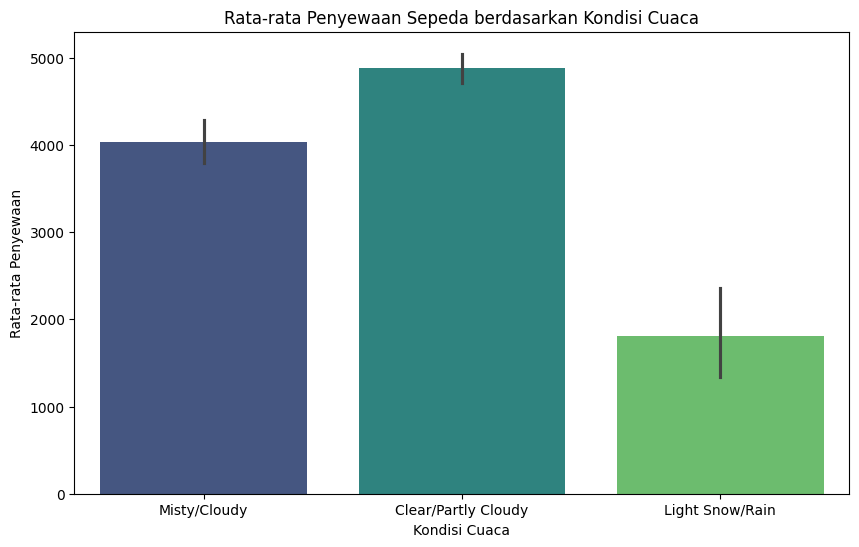

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='weathersit',
    y='cnt',
    data=day_df,
    palette='viridis'
)
plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

### Pertanyaan 2:

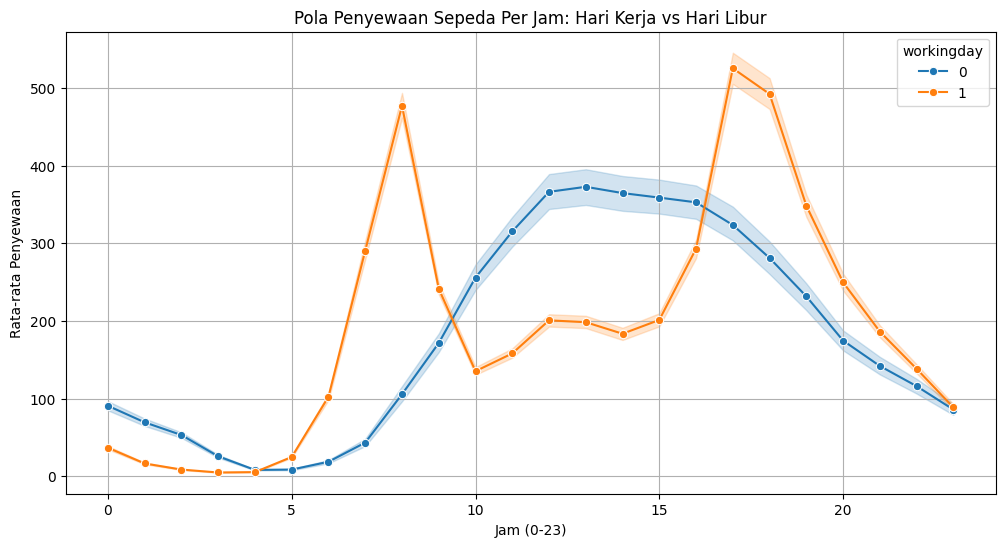

In [39]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='hr',
    y='cnt',
    data=hour_df,
    hue='workingday',
    marker='o'
)
plt.title('Pola Penyewaan Sepeda Per Jam: Hari Kerja vs Hari Libur')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Penyewaan')
plt.grid(True)
plt.show()

**Insight:** (Opsional)
- Insight Visualisasi 1 (Kondisi Cuaca):
a. Grafik batang menunjukkan bahwa rata-rata penyewaan tertinggi terjadi pada kondisi cuaca 1 (Clear/Partly Cloudy). Terdapat penurunan yang konsisten seiring memburuknya cuaca ke tingkat 2 (Misty) dan tingkat 3 (Light Snow/Rain).

b. Terjadi penurunan drastis (lebih dari 50%) saat cuaca berubah dari cerah ke hujan/salju ringan. Ini mengindikasikan bahwa operasional penyewaan sangat bergantung pada kondisi cuaca harian.

- Insight Visualisasi 2 (Pola Per Jam):
a. Pada hari kerja (workingday 1), terlihat dua puncak tajam (peak hours) yaitu pada jam 08:00 pagi dan 17:00 sore. Ini memperkuat bukti bahwa pengguna utama pada hari kerja adalah pekerja/pelajar.

b. Berbeda dengan hari kerja, pola hari libur (workingday 0) menunjukkan kenaikan bertahap yang puncaknya terjadi di tengah hari (jam 12:00 - 16:00). Ini mencerminkan penggunaan sepeda untuk tujuan rekreasi atau olahraga.

c. Titik Terendah: Kedua kategori hari memiliki titik penggunaan terendah yang sama pada dini hari (jam 00:00 - 04:00), yang merupakan waktu istirahat umum.

## Analisis Lanjutan (Opsional)

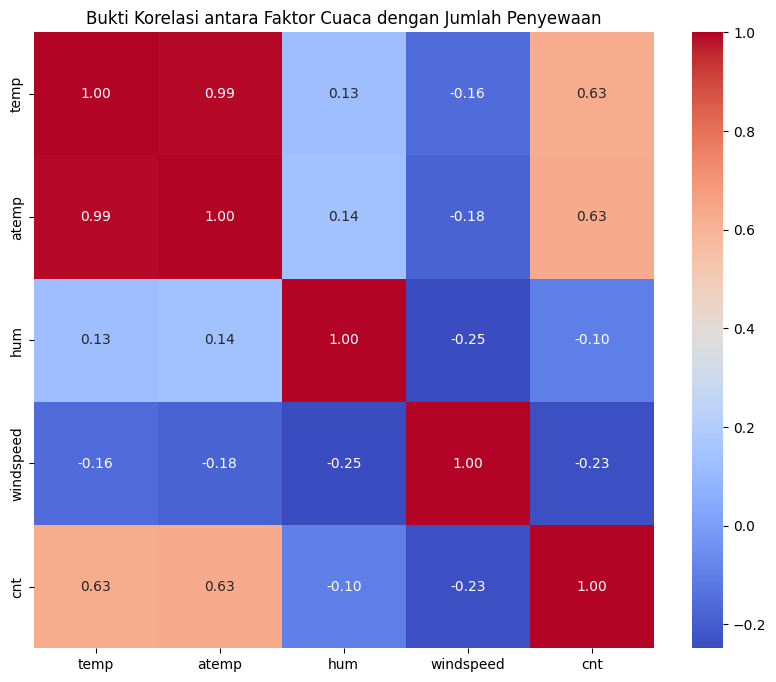

In [40]:
# Melihat korelasi antara variabel numerik dengan jumlah penyewaan
plt.figure(figsize=(10, 8))
correlation_matrix = day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Bukti Korelasi antara Faktor Cuaca dengan Jumlah Penyewaan')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca cerah/berawan adalah waktu puncak penyewaan sepeda. Sebaliknya, cuaca hujan atau bersalju menyebabkan penurunan drastis pada jumlah penyewa karena faktor keamanan dan kenyamanan.
- **Conclusion pertanyaan 2:** Pola penggunaan sepeda di hari kerja sangat berbeda dengan hari libur. Hari kerja didominasi oleh mobilitas komuter (pagi dan sore), sementara hari libur didominasi oleh aktivitas rekreasi yang memuncak di siang hingga sore hari secara lebih landai.

**Rekomendasi Action Item:**
- Melakukan pengecekan dan perawatan armada pada jam 10:00 - 14:00 di hari kerja, karena pada jam tersebut penggunaan sedang menurun di antara dua jam sibuk.
- Memberikan promo atau insentif khusus pada hari-hari dengan kelembapan tinggi atau angin kencang untuk menarik minat pengguna yang cenderung turun pada kondisi tersebut.
- Memastikan ketersediaan unit sepeda yang cukup di titik-titik transportasi publik pada jam 07:00 pagi dan di pusat perkantoran pada jam 16:00 sore selama hari kerja.